In [1]:
import cv2

In [6]:
import cv2
import numpy as np

# load image
img = cv2.imread('download.jpg', 0)
img = cv2.resize(img, (200, 200))

# simple convolution
def conv(img, kernel):
    k = len(kernel)
    pad = k // 2

    img = img.astype(np.float32)
    padded = np.pad(img, pad)
    out = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+k, j:j+k]
            out[i, j] = np.sum(region * kernel)

    return out

# normalize for display
def norm(img):
    # return (255 * np.abs(img) / np.max(np.abs(img))).astype(np.uint8)
    img_norm = (img - img.min()) / (img.max() - img.min())
    img_norm = (img_norm * 255).astype(np.uint8)
    return img_norm

Task 1: Diagonal Detect


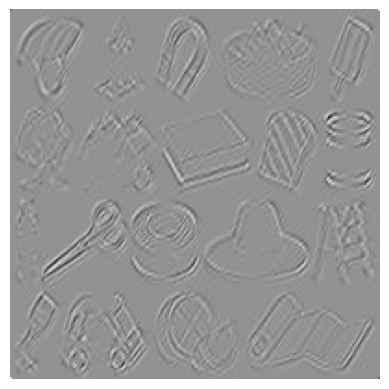

In [11]:

import matplotlib.pyplot as plt

    
def cv2_imshow(image):
    if image.ndim == 2:
        plt.imshow(image, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


mask_diag = [[-1, -1, 2],
             [-1,  2, -1],
             [ 2, -1, -1]]

res_diag = conv(img, mask_diag)

print("Task 1: Diagonal Detect")
cv2_imshow(norm(res_diag))


Task 2: Horizontal Detect


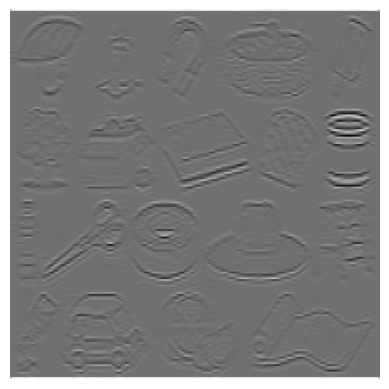

In [12]:
mask_horiz = [[-1, -1, -1],
              [ 2,  2,  2],
              [-1, -1, -1]]

res_horiz = conv(img, mask_horiz)
print("Task 2: Horizontal Detect")
cv2_imshow(norm(res_horiz))

Task 3: Vertical Detect


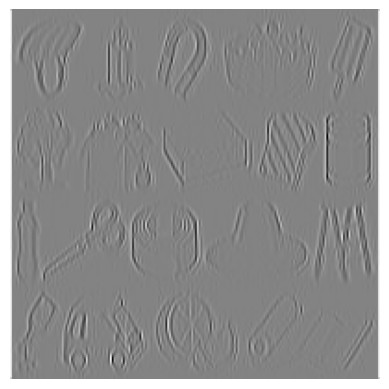

In [13]:
mask_vert = [[-1, 2, -1],
             [-1, 2, -1],
             [-1, 2, -1]]

res_vert = conv(img, mask_vert)
print("Task 3: Vertical Detect")
cv2_imshow(norm(res_vert))

Task 4: Sobel Operator


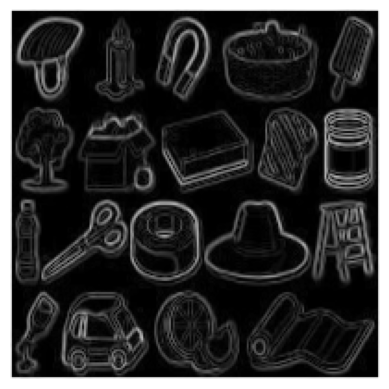

In [14]:
sobel_x = [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]
sobel_y = [[-1, -2, -1], [0, 0, 0], [1, 2, 1]]

s_x = conv(img, sobel_x)
s_y = conv(img, sobel_y)
sobel_mag = np.sqrt(s_x**2 + s_y**2)
print("Task 4: Sobel Operator")
cv2_imshow(norm(sobel_mag))

Task 5: Prewitt Operator


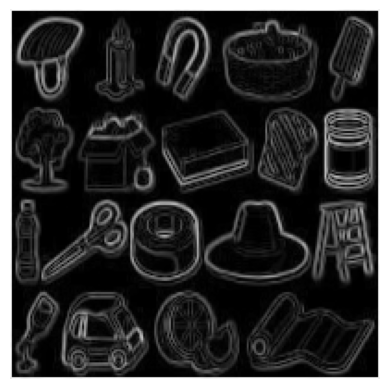

In [15]:
prewitt_x = [[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]
prewitt_y = [[-1, -1, -1], [0, 0, 0], [1, 1, 1]]

p_x = conv(img, prewitt_x)
p_y = conv(img, prewitt_y)
prewitt_mag = np.sqrt(p_x**2 + p_y**2)
print("Task 5: Prewitt Operator")
cv2_imshow(norm(prewitt_mag))


Task 6: Canny Edges


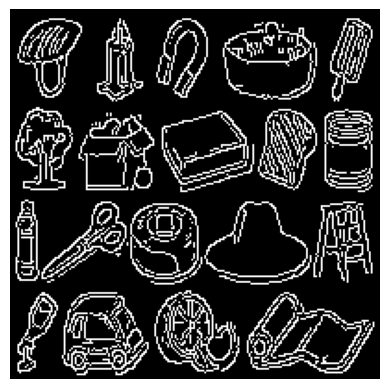

In [16]:
canny_edges = cv2.Canny(img, 100, 200)
print("Task 6: Canny Edges")
cv2_imshow(canny_edges)

Task 7: Gabor Filter


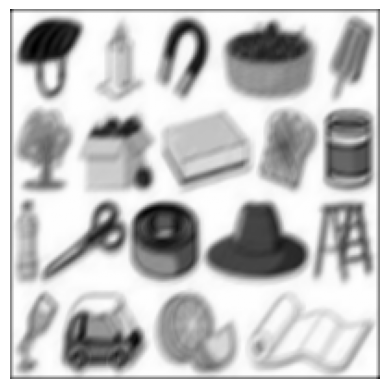

In [18]:
# Generate the Gabor kernel using cv2, then apply with our loops
gabor_kernel = cv2.getGaborKernel((5, 5), 4.0, np.pi/4, 10.0, 0.5, 0, ktype=cv2.CV_32F)

res_gabor = conv(img, gabor_kernel)
print("Task 7: Gabor Filter")
cv2_imshow(norm(res_gabor))

Task 8: Sharpened


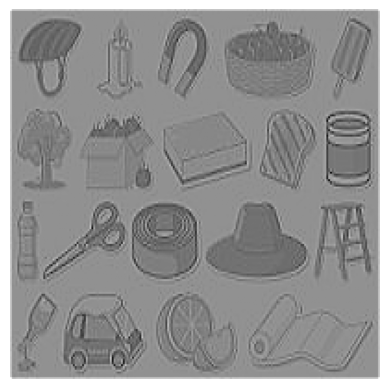

In [19]:
sharpen_mask = [[ 0, -1,  0],
                [-1,  5, -1],
                [ 0, -1,  0]]

res_sharpen = conv(img, sharpen_mask)
print("Task 8: Sharpened")
cv2_imshow(norm(res_sharpen))

Task 9: Noise -> Blur -> Sobel


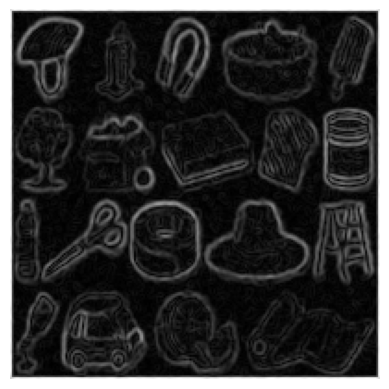

In [21]:
# 1. Add Gaussian Noise
noise = np.random.normal(0, 25, img.shape).astype(np.float32)
noisy_img = np.clip(img + noise, 0, 255).astype(np.uint8)

# 2. Blur Filter
gaussian_kernel = (1/16) * np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]])
blurred_img = conv(noisy_img, gaussian_kernel)
# blurred_img = cv2.GaussianBlur(noisy_img, (3,3), 0)

# 3. Edge Detection (Sobel as example)
sobel_x = [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]
sobel_y = [[-1, -2, -1], [0, 0, 0], [1, 2, 1]]

noise_sobel_x = conv(blurred_img, sobel_x)
noise_sobel_y = conv(blurred_img, sobel_y)
noise_sobel_mag = norm(np.sqrt(noise_sobel_x**2 + noise_sobel_y**2))
print("Task 9: Noise -> Blur -> Sobel")
cv2_imshow(noise_sobel_mag)

In [22]:
# Using the Canny edges from Task 6 to count, as they are cleanly thresholded
canny_edges = cv2.Canny(img, 100, 200)

edge_pixel_count = np.sum(canny_edges > 0)
print(f"Total Edge Pixels Detected: {edge_pixel_count}")

Total Edge Pixels Detected: 6461


Task 10: Laplacian of Gaussian (LoG)


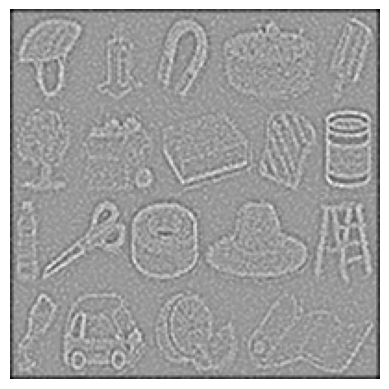

In [23]:
# Assuming 'blurred_img' from Task 9, or compute a new one.
laplacian_kernel = [[ 0,  1,  0],
                    [ 1, -4,  1],
                    [ 0,  1,  0]]

res_log = conv(blurred_img, laplacian_kernel)
print("Task 10: Laplacian of Gaussian (LoG)")
cv2_imshow(norm(res_log))

Task 12: Edges Only (Masked)


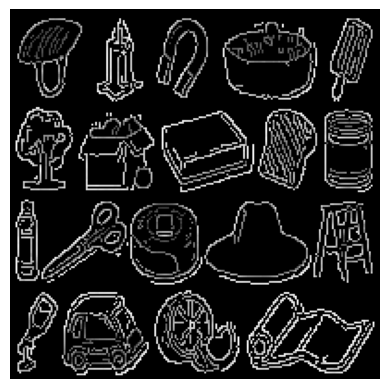

In [24]:
canny_edges = cv2.Canny(img, 100, 200)

# Use the binary edge map as a mask over the original image
edges_only = cv2.bitwise_and(img, img, mask=canny_edges)
print("Task 12: Edges Only (Masked)")
cv2_imshow(edges_only)

Task 13: Bounding Boxes


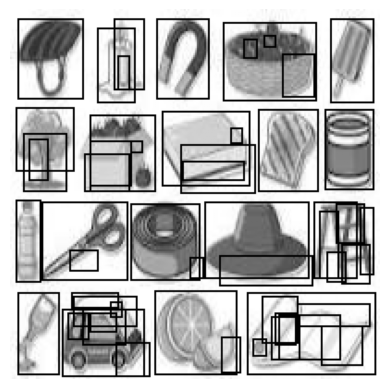

In [25]:
canny_edges = cv2.Canny(img, 100, 200)
contours, _ = cv2.findContours(canny_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

bbox_img = img.copy()

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    # Filter out extremely small noise points
    if w > 5 and h > 5:
        cv2.rectangle(bbox_img, (x, y), (x+w, y+h), (0, 255, 0), 1)
print("Task 13: Bounding Boxes")
cv2_imshow(bbox_img)